<a href="https://colab.research.google.com/github/greek-nlp/benchmark/blob/main/gr_retrieval_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Barzokas Retrieval Analysis


In [4]:
import os
import shutil
import subprocess
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
repo_root = Path('/content/benchmark')
if not repo_root.exists():
    subprocess.run(['git', 'clone', 'https://github.com/greek-nlp/benchmark.git', str(repo_root)], check=True)
os.chdir(repo_root)

In [19]:
%%capture
!pip install zenodo-get wget
!pip install datasets
!pip install conll-df
import importlib

gr_data = pd.read_csv('data.csv')
gena = importlib.import_module("data_wrapper")
barzokas = gena.BarzokasDt(datasets=gr_data)
barzokas_df = pd.concat([barzokas.get('train'), barzokas.get('test')])

Download github items in directory: /content/benchmark/repo_56
Successfully downloaded data/corpora


In [22]:
# Keep retrieval columns
retrieval_df = barzokas_df[['title', 'text', 'author']].copy()
retrieval_df['title'] = retrieval_df['title'].fillna('').astype(str).str.strip()
retrieval_df['text'] = retrieval_df['text'].fillna('').astype(str).str.strip()
retrieval_df['author'] = retrieval_df['author'].fillna('UNKNOWN').astype(str).str.strip()

print('Retrieval rows:', len(retrieval_df))
retrieval_df.head()

Retrieval rows: 3266


,title,text,author
0,Κάποτε στο Μεσολόγγι,Οδυσσέας ΔαγκλήςΚάποτε στο ΜεσολόγγιΔιηγήματαΚ...,Οδυσσέας Δαγκλής
1,Το παραμύθι και η Δημιουργική Γραφή στο σχολείο,www.selfpublishingonline.eu http://selfpublis...,Δήμος Βελέντζας
2,"Ταντίνιο, το χαμογελαστό κοχύλι","Ταντίνιο, το χαμογελαστό κοχύλιΤαντίνιο,το χαμ...",Κώστας Θερμογιάννης
3,Οι πέντε σφραγίδες και ο χαμένος πρίγκιπας,Οι πέντε σφραγίδες και ο χαμένος Πρίγκιπας ...,Στέλλα Χαβενετίδου
4,"Μετρώντας τα τραγούδια, αμέτρητα",Άκης ΠάνουΠάνος Α. ΖέρβαςΜετρώντας τα τραγούδι...,Πάνος Α. Ζέρβας


In [23]:
# Sample titles (query examples)
sample_n = min(20, len(retrieval_df))
title_samples = retrieval_df[['title', 'author']].sample(n=sample_n, random_state=42).reset_index(drop=True)
title_samples

,title,author
0,Οδός Βράχων: Ανατολικά,Αχιλλέας Κατσαρός
1,Ο Αυτοκράτωρ Ηράκλειος,"Karolides, Paulos"
2,Κρούγκερ,Δημήτρης Κωνσταντίνου
3,Σέρλοκ Χολμς – Η Κοιλάδα του Φόβου,"Άρθουρ Κόναν Ντόυλ (Arthur Conan Doyle, 1859-1..."
4,Οι μυθοσυλλέκτες,Γιάννης Αντάμης
5,Reqviem,"Χοσέ Ιέρρο (José Hierro, 1922-2002)"
6,Η Δρακοφιλίτσα,Μαρία Χατζή
7,Για αύριο,Γιάννης Αντάμης
8,Σαικσπείρου Τραγωδίαι : Μέρος Α'. Ρωμαίος και ...,"Shakespeare, William"
9,Μια μπουνιά κι ένα φιλί,Βασίλειος Κάππας


In [24]:
# Token-level statistics (whitespace tokenization)
def token_count(text: str) -> int:
    return len(text.split()) if isinstance(text, str) and text else 0

retrieval_df['title_tokens'] = retrieval_df['title'].apply(token_count)
retrieval_df['text_tokens'] = retrieval_df['text'].apply(token_count)

token_stats = pd.DataFrame({
    'title_tokens': retrieval_df['title_tokens'],
    'text_tokens': retrieval_df['text_tokens'],
}).describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95]).T

token_stats['total_tokens'] = [
    retrieval_df['title_tokens'].sum(),
    retrieval_df['text_tokens'].sum(),
]

token_stats

,count,mean,std,min,25%,50%,75%,90%,95%,max,total_tokens
title_tokens,3266.0,4.090631,2.817098,1.0,2.00,4.0,5.00,7.0,9.0,30.0,13360
text_tokens,3266.0,21418.403858,37612.279380,0.0,2033.25,8544.5,24989.25,54645.5,82406.0,417129.0,69952507


In [25]:
# Authors: count and distribution
n_authors = retrieval_df['author'].nunique()
print('Unique authors:', n_authors)

author_dist = retrieval_df['author'].value_counts().rename_axis('author').reset_index(name='count')
author_dist['percentage'] = (author_dist['count'] / len(retrieval_df) * 100).round(2)
author_dist.head(30)

Unique authors: 622


,author,count,percentage
0,Γιάννης Αντάμης,90,2.76
1,Θανάσης Τριαρίδης,86,2.63
2,Κώστας Βουλαζέρης,56,1.71
3,Πάνος Κολιόπουλος,52,1.59
4,Δημήτρης Τζουβάλης,46,1.41
5,Plato,40,1.22
6,Ράνια Συνοδινού,39,1.19
7,Βασίλης Λαλιώτης,31,0.95
8,Αντώνης Αντωνάκος,30,0.92
9,Ευρυδίκη Αμανατίδου,27,0.83


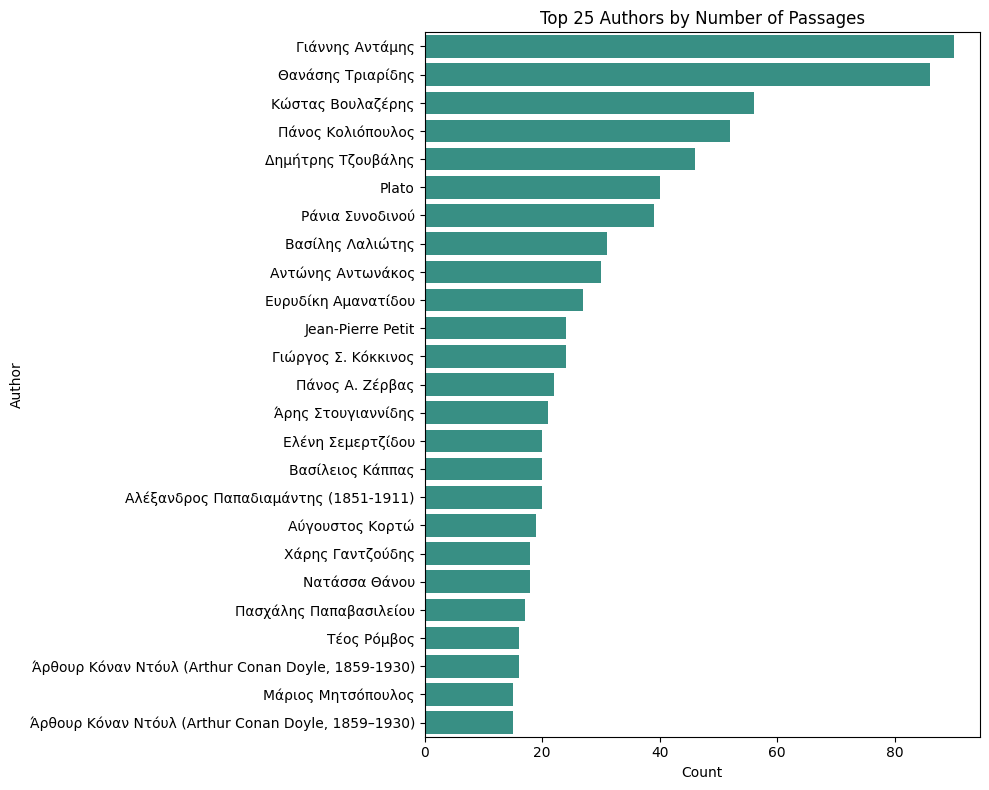

In [26]:
# Author distribution plot (top 25)
top_k = 25
plot_df = author_dist.head(top_k).copy()

plt.figure(figsize=(10, 8))
sns.barplot(data=plot_df, y='author', x='count', color='#2a9d8f')
plt.title(f'Top {top_k} Authors by Number of Passages')
plt.xlabel('Count')
plt.ylabel('Author')
plt.tight_layout()
plt.show()

## Metadata / Cleaning Investigation

The cells below help verify whether `text` starts with metadata-like prefixes (e.g. `Title:`, `Author:`, `ISBN`, `publishedYear`) before the actual passage content.

In [ ]:
import re

# Regex patterns for metadata-like content near the beginning of each text
metadata_patterns = [
    (r'^\s*(title|τίτλος)\s*[:\-]', 'title_prefix'),
    (r'^\s*(author|συγγραφ[έε]ας)\s*[:\-]', 'author_prefix'),
    (r'^\s*(isbn|issn)\s*[:\-]', 'isbn_prefix'),
    (r'^\s*(publisher|εκδότ[ηη]ς)\s*[:\-]', 'publisher_prefix'),
    (r'^\s*(published\s*year|year|έτος)\s*[:\-]', 'year_prefix'),
    (r'^\s*(id|doc\s*id|document\s*id)\s*[:\-]', 'id_prefix'),
    (r'^\s*(source|πηγ[ήη])\s*[:\-]', 'source_prefix'),
    (r'^\s*<{0,1}[A-Za-z_]+>{0,1}\s*[:\-]', 'generic_tag_prefix'),
]

def detect_metadata_prefix(text: str):
    if not isinstance(text, str):
        return []
    head = text[:500]  # inspect first 500 chars
    hits = []
    for pattern, name in metadata_patterns:
        if re.search(pattern, head, flags=re.IGNORECASE):
            hits.append(name)
    return hits

retrieval_df['metadata_hits'] = retrieval_df['text'].apply(detect_metadata_prefix)
retrieval_df['has_metadata_prefix'] = retrieval_df['metadata_hits'].apply(lambda x: len(x) > 0)

n_total = len(retrieval_df)
n_flagged = int(retrieval_df['has_metadata_prefix'].sum())
print(f'Total rows: {n_total}')
print(f'Rows with metadata-like prefix: {n_flagged} ({(n_flagged / n_total * 100 if n_total else 0):.2f}%)')

retrieval_df['metadata_hits'].explode().value_counts(dropna=True).rename_axis('pattern').reset_index(name='count')

In [ ]:
# Show suspicious examples (beginning of text only)
suspicious = retrieval_df[retrieval_df['has_metadata_prefix']].copy()

if suspicious.empty:
    print('No clear metadata-like prefixes detected with current rules.')
else:
    preview_cols = ['author', 'title', 'metadata_hits']
    display_df = suspicious[preview_cols].head(20).copy()
    display_df['text_start'] = suspicious['text'].str[:350].str.replace('\n', ' ', regex=False)
    display_df

In [ ]:
# Heuristic metadata stripping (for inspection, not permanent rewrite)
strip_patterns = [
    r'^\s*(title|τίτλος)\s*[:\-].*?$\n?',
    r'^\s*(author|συγγραφ[έε]ας)\s*[:\-].*?$\n?',
    r'^\s*(isbn|issn)\s*[:\-].*?$\n?',
    r'^\s*(publisher|εκδότ[ηη]ς)\s*[:\-].*?$\n?',
    r'^\s*(published\s*year|year|έτος)\s*[:\-].*?$\n?',
    r'^\s*(id|doc\s*id|document\s*id)\s*[:\-].*?$\n?',
    r'^\s*(source|πηγ[ήη])\s*[:\-].*?$\n?',
]

def strip_leading_metadata_block(text: str, max_lines: int = 12) -> str:
    if not isinstance(text, str) or not text:
        return text

    lines = text.splitlines()
    i = 0
    while i < min(len(lines), max_lines):
        line = lines[i]
        matched = any(re.search(p, line, flags=re.IGNORECASE) for p in strip_patterns)
        if matched or line.strip() == '':
            i += 1
            continue
        break

    # Remove only the matched leading block
    return '\n'.join(lines[i:]).strip() if i > 0 else text.strip()

retrieval_df['text_clean_probe'] = retrieval_df['text'].apply(strip_leading_metadata_block)
retrieval_df['text_tokens_clean_probe'] = retrieval_df['text_clean_probe'].apply(token_count)
retrieval_df['token_delta_probe'] = retrieval_df['text_tokens'] - retrieval_df['text_tokens_clean_probe']

probe_summary = {
    'rows_with_token_reduction': int((retrieval_df['token_delta_probe'] > 0).sum()),
    'mean_token_reduction': float(retrieval_df['token_delta_probe'].mean()),
    'max_token_reduction': int(retrieval_df['token_delta_probe'].max()),
}
probe_summary

In [ ]:
# Inspect rows most affected by metadata stripping heuristic
most_affected = retrieval_df.sort_values('token_delta_probe', ascending=False).head(20).copy()
most_affected = most_affected[most_affected['token_delta_probe'] > 0]

if most_affected.empty:
    print('No rows were reduced by the stripping heuristic.')
else:
    cols = ['author', 'title', 'token_delta_probe', 'text_tokens', 'text_tokens_clean_probe']
    out = most_affected[cols].copy()
    out['original_start'] = most_affected['text'].str[:250].str.replace('\n', ' ', regex=False)
    out['cleaned_start'] = most_affected['text_clean_probe'].str[:250].str.replace('\n', ' ', regex=False)
    out

## Plain Front-Matter Investigation (No Tags)

This block detects metadata embedded as raw text at the beginning (author/title/ISBN/contact/publisher), even when no explicit `Title:` or `Author:` labels exist.

In [ ]:
import re

# Focus on the beginning of each text where front-matter usually appears
HEAD_CHARS = 1800

# Signals frequently found in publishing metadata front-matter
raw_metadata_regexes = {
    'isbn': r'\bISBN\b',
    'email': r'\b[eE]-?mail\b|[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}',
    'website': r'\bwebsite\b|www\.|https?://',
    'phone': r'\b(Τ\.|T\.|Κ\.|K\.)\s*[:.]|\b\d{10}\b',
    'publisher_word': r'\b(Εκδόσεις|εκδόσεις|publications|Publications)\b',
    'creative_commons': r'Creative\s+Commons|Άδεια\s+Creative\s+Commons',
    'address_hint': r'\b(οδός|street|\d{1,4},\s*\d{5})\b',
    'month_year': r'\b(Ιανουάριος|Φεβρουάριος|Μάρτιος|Απρίλιος|Μάιος|Ιούνιος|Ιούλιος|Αύγουστος|Σεπτέμβριος|Οκτώβριος|Νοέμβριος|Δεκέμβριος)\s+\d{4}\b',
}


def count_occurrences_in_head(text: str, phrase: str, head_chars: int = HEAD_CHARS) -> int:
    if not isinstance(text, str) or not isinstance(phrase, str):
        return 0
    phrase = phrase.strip()
    if not phrase:
        return 0
    head = text[:head_chars]
    return head.count(phrase)


def raw_metadata_signal_counts(text: str) -> dict:
    if not isinstance(text, str):
        return {k: 0 for k in raw_metadata_regexes}
    head = text[:HEAD_CHARS]
    out = {}
    for k, rx in raw_metadata_regexes.items():
        out[k] = len(re.findall(rx, head, flags=re.IGNORECASE))
    return out


# Author/title repetition in the opening chunk is a strong front-matter signal
retrieval_df['author_in_head_count'] = retrieval_df.apply(
    lambda r: count_occurrences_in_head(r['text'], r['author']), axis=1
)
retrieval_df['title_in_head_count'] = retrieval_df.apply(
    lambda r: count_occurrences_in_head(r['text'], r['title']), axis=1
)

signal_dicts = retrieval_df['text'].apply(raw_metadata_signal_counts)
signal_df = pd.DataFrame(signal_dicts.tolist()).fillna(0).astype(int)
for col in signal_df.columns:
    retrieval_df[f'signal_{col}'] = signal_df[col]

signal_cols = [f'signal_{k}' for k in raw_metadata_regexes]
retrieval_df['front_matter_signal_total'] = retrieval_df[signal_cols].sum(axis=1)

# Heuristic: flagged if opening contains repeated author/title and/or multiple metadata signals
retrieval_df['has_plain_front_matter'] = (
    (retrieval_df['author_in_head_count'] >= 2)
    | (retrieval_df['title_in_head_count'] >= 2)
    | (retrieval_df['front_matter_signal_total'] >= 2)
)

n_total = len(retrieval_df)
n_flagged = int(retrieval_df['has_plain_front_matter'].sum())
print(f'Total rows: {n_total}')
print(f'Rows flagged for plain front-matter: {n_flagged} ({(n_flagged / n_total * 100 if n_total else 0):.2f}%)')

retrieval_df[[
    'author_in_head_count',
    'title_in_head_count',
    'front_matter_signal_total',
    *signal_cols,
]].describe().T

In [ ]:
# Inspect flagged examples (start of text)
flagged = retrieval_df[retrieval_df['has_plain_front_matter']].copy()

if flagged.empty:
    print('No rows flagged by the plain front-matter heuristic.')
else:
    show_cols = [
        'author', 'title',
        'author_in_head_count', 'title_in_head_count',
        'front_matter_signal_total'
    ]
    out = flagged[show_cols].head(25).copy()
    out['text_head'] = flagged['text'].str[:700].str.replace('\n', ' ', regex=False)
    out

In [ ]:
# Probe cleaner: trim leading lines while metadata-like signals dominate

def strip_plain_front_matter(text: str, author: str, title: str, max_lines: int = 35) -> str:
    if not isinstance(text, str) or not text:
        return text

    lines = text.splitlines()
    if len(lines) == 1:
        # single-line blobs: fallback to weak split heuristic around first long sentence punctuation
        # keep conservative to avoid over-trimming
        return text.strip()

    kept_from = 0
    for i in range(min(len(lines), max_lines)):
        line = lines[i].strip()
        if not line:
            kept_from = i + 1
            continue

        low = line.lower()
        author_hit = isinstance(author, str) and author.strip() and author.strip().lower() in low
        title_hit = isinstance(title, str) and title.strip() and title.strip().lower() in low
        rx_hit = any(re.search(rx, line, flags=re.IGNORECASE) for rx in raw_metadata_regexes.values())

        # Consider line as front-matter if it is mostly metadata-like
        if author_hit or title_hit or rx_hit:
            kept_from = i + 1
            continue

        # first non-metadata line becomes likely content start
        break

    cleaned = '\n'.join(lines[kept_from:]).strip() if kept_from > 0 else text.strip()
    return cleaned if cleaned else text.strip()

retrieval_df['text_plain_clean_probe'] = retrieval_df.apply(
    lambda r: strip_plain_front_matter(r['text'], r['author'], r['title']), axis=1
)
retrieval_df['text_tokens_plain_clean_probe'] = retrieval_df['text_plain_clean_probe'].apply(token_count)
retrieval_df['plain_token_delta_probe'] = retrieval_df['text_tokens'] - retrieval_df['text_tokens_plain_clean_probe']

summary_probe = {
    'rows_with_token_reduction': int((retrieval_df['plain_token_delta_probe'] > 0).sum()),
    'mean_token_reduction': float(retrieval_df['plain_token_delta_probe'].mean()),
    'max_token_reduction': int(retrieval_df['plain_token_delta_probe'].max()),
}
summary_probe

In [ ]:
# Most affected rows after plain front-matter stripping probe
affected = retrieval_df.sort_values('plain_token_delta_probe', ascending=False).head(20).copy()
affected = affected[affected['plain_token_delta_probe'] > 0]

if affected.empty:
    print('No rows reduced by plain front-matter stripping probe.')
else:
    cols = [
        'author', 'title', 'plain_token_delta_probe', 'text_tokens', 'text_tokens_plain_clean_probe',
        'author_in_head_count', 'title_in_head_count', 'front_matter_signal_total'
    ]
    out = affected[cols].copy()
    out['original_head'] = affected['text'].str[:350].str.replace('\n', ' ', regex=False)
    out['cleaned_head'] = affected['text_plain_clean_probe'].str[:350].str.replace('\n', ' ', regex=False)
    out